# Matplotlib Practice

Seaborn is built on top of Matplotlib, and every Seaborn function
returns real Matplotlib `Axes`/`Figure` objects. This short
supplementary notebook practices the raw-Matplotlib skills that make
customizing Seaborn plots (multi-panel figures, manual annotations,
fine axis control) much easier, using the same `qc_metrics.csv`
dataset as the main tutorial.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA = Path.cwd().parent / "data"
df = pd.read_csv(DATA / "qc_metrics.csv")
df.head()

,sample_id,batch,coverage_mean,duplicates_pct,gc_content,q30_pct
0,SMP000,batch_3,72.37,11.57,37.53,95.54
1,SMP001,batch_1,55.45,14.60,39.17,93.69
2,SMP002,batch_1,49.32,22.35,43.38,93.38
3,SMP003,batch_3,73.50,16.89,41.54,95.07
4,SMP004,batch_3,66.79,15.41,39.02,94.47


## 1. Figure and Axes objects

Every plot is a `Figure` containing one or more `Axes`. Understanding
this is essential for building multi-panel figures. Seaborn's
`ax=` parameter (used throughout `bioviz`) accepts exactly these
objects.

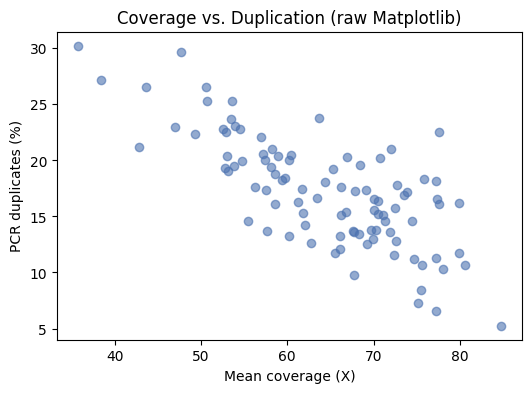

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df["coverage_mean"], df["duplicates_pct"], alpha=0.6, color="#4C72B0")
ax.set_xlabel("Mean coverage (X)")
ax.set_ylabel("PCR duplicates (%)")
ax.set_title("Coverage vs. Duplication (raw Matplotlib)")
plt.show()

## 2. Multi-panel figures with `plt.subplots`

`plt.subplots(nrows, ncols)` returns a grid of Axes you can index and
fill independently, the standard way to build a multi-panel summary
figure combining several `bioviz` plots.

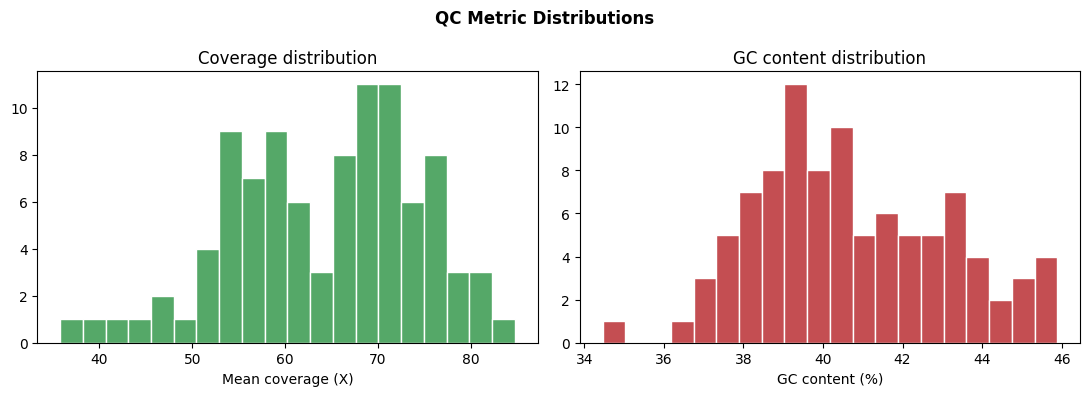

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df["coverage_mean"], bins=20, color="#55A868", edgecolor="white")
axes[0].set_title("Coverage distribution")
axes[0].set_xlabel("Mean coverage (X)")

axes[1].hist(df["gc_content"], bins=20, color="#C44E52", edgecolor="white")
axes[1].set_title("GC content distribution")
axes[1].set_xlabel("GC content (%)")

fig.suptitle("QC Metric Distributions", fontweight="bold")
fig.tight_layout()
plt.show()

## 3. Annotating specific points

A common need: flag samples that fail a QC threshold directly on the
plot rather than in a separate table.

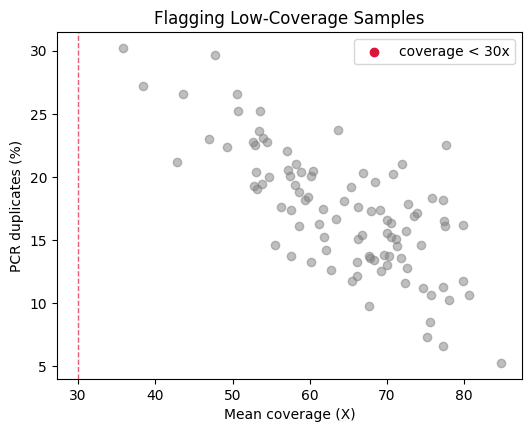

In [4]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(df["coverage_mean"], df["duplicates_pct"], alpha=0.5, color="gray")

low_cov = df[df["coverage_mean"] < 30]
ax.scatter(low_cov["coverage_mean"], low_cov["duplicates_pct"], color="crimson", label="coverage < 30x")
for _, row in low_cov.head(3).iterrows():
    ax.annotate(
        row["sample_id"],
        (row["coverage_mean"], row["duplicates_pct"]),
        textcoords="offset points", xytext=(5, 5), fontsize=8,
    )

ax.axvline(30, color="crimson", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("Mean coverage (X)")
ax.set_ylabel("PCR duplicates (%)")
ax.set_title("Flagging Low-Coverage Samples")
ax.legend()
plt.show()

## 4. Saving publication-quality figures

`bioviz.theme.savefig` wraps this pattern, but it's worth knowing the
raw call: high DPI, tight bounding box, and a vector-friendly format
for anything headed to a manuscript.

In [5]:
FIGS = Path.cwd().parent / "figures"
fig.savefig(FIGS / "practice_annotated_qc.png", dpi=300, bbox_inches="tight")
print("saved figures/practice_annotated_qc.png")

saved figures/practice_annotated_qc.png


## Next

With these Matplotlib basics in hand, head to
`seaborn_beginner_guide.ipynb` for the full plot-type tour. Every
figure there is a Seaborn call that ultimately returns the same
`Figure`/`Axes` objects you just worked with directly.